# GLM-5.3-Flash NVFP4 on 2x DGX Spark

| Metric | Value | Source |
|---|---|---|
| Decode, c=1 | 26.55 tok/s (median of 3) | canonical receipt, 2026-08-27 |
| Best aggregate throughput | 82.12 tok/s @ c=7 (median of 3) | canonical receipt, 2026-08-27 |
| Prefill (uncached, 4K) | 1,371.87 input tok/s (median of 3) | canonical receipt, 2026-08-27 |
| TTFT, decode c=1 | 0.432 s (median of 3) | canonical receipt, 2026-08-27 |

Backfill notebook: all numbers are replayed from the sanitized receipts in
`results/2026-08-27-glm-5.3-flash-nvfp4-2node/`; no measurement in this notebook was taken for it.

```bash
huggingface-cli download LibertAIDAI/GLM-5.3-Flash-NVFP4 --revision 11d73216cd636238e82e1d77fe1042ffab36e7fa
```

Evidence: [PixelML/GLM-5.3-Flash-NVFP4-Dual-DGX-Spark](https://github.com/PixelML/GLM-5.3-Flash-NVFP4-Dual-DGX-Spark) · Checkpoint: [LibertAIDAI/GLM-5.3-Flash-NVFP4](https://huggingface.co/LibertAIDAI/GLM-5.3-Flash-NVFP4)

## GLM-5.3-Flash NVFP4 — 2x DGX Spark, vLLM TP=2

Executed notebook. Every cell output below is committed; see
`notebooks/README.md` for the section order and the `LIVE` flag convention.
Section 1 is the verdict, section 2 shows every result the receipts contain,
section 3 reproduces the deployment, and the appendix holds the failure
history.

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/2026-08-27-glm-5.3-flash-nvfp4-2node/.
# LIVE = True runs a small live harness (service check + one fixed-256-token
# c=1 decode) against a running OpenAI-compatible endpoint whose base URL
# comes from the GLM_ENDPOINT environment variable. Never hardcode an
# endpoint address in this notebook. This notebook's committed outputs were
# produced with LIVE = False (receipt replay only; the measurements date to
# 2026-08-27/28 and live in the evidence repository).
import os

EXPERIMENT = "2026-08-27-glm-5.3-flash-nvfp4-2node"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
SERVED_MODEL_ID = "LibertAIDAI/GLM-5.3-Flash-NVFP4"
GLM_ENDPOINT = os.environ.get("GLM_ENDPOINT", "").rstrip("/")

print("LIVE =", LIVE)
print("results dir:", RESULTS_DIR)
if LIVE:
    assert GLM_ENDPOINT, "Set GLM_ENDPOINT to your own endpoint base URL before running with LIVE=True."
    print("endpoint: <set via GLM_ENDPOINT env var, not printed>")

LIVE = False
results dir: ../results/2026-08-27-glm-5.3-flash-nvfp4-2node


In [2]:
# --- Helpers -------------------------------------------------------------
import json
from IPython.display import display, Markdown, Image


def load_receipt(name):
    with open(os.path.join(RESULTS_DIR, name)) as f:
        return json.load(f)


def render_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


# Fixed decode protocol from the receipts: compact Python topological-order
# validator prompt, reasoning_effort=low, temperature=0, ignore_eos=true,
# exactly 256 output tokens, tokens counted from the final usage object.
LIVE_PROMPT = (
    "Write a compact Python function `is_valid_order(seq, edges)` that "
    "returns True iff `seq` is a valid topological order of the DAG given "
    "by `edges`. Include two short assertions."
)


def live_c1_decode():
    import time
    import requests
    payload = {
        "model": SERVED_MODEL_ID,
        "messages": [{"role": "user", "content": LIVE_PROMPT}],
        "reasoning_effort": "low",
        "temperature": 0,
        "max_tokens": 256,
        "ignore_eos": True,
    }
    t0 = time.perf_counter()
    r = requests.post(f"{GLM_ENDPOINT}/chat/completions", json=payload, timeout=300)
    wall_s = time.perf_counter() - t0
    r.raise_for_status()
    usage = r.json()["usage"]  # count tokens from the final usage object only
    return {
        "wall_s": wall_s,
        "completion_tokens": usage["completion_tokens"],
        "finish_reason": r.json()["choices"][0]["finish_reason"],
        "tok_s": usage["completion_tokens"] / wall_s,
    }

In [3]:
# --- Live-mode measurement (runs only when LIVE = True) ------------------
if LIVE:
    m = live_c1_decode()
    print("finish_reason:", m["finish_reason"])
    print("completion tokens (final usage object):", m["completion_tokens"])
    print(f"e2e tok/s: {m['tok_s']:.2f}")
    print("compare with the canonical c=1 rows below; your host config will move the number")
else:
    print("LIVE = False: replaying the committed receipts (no network, no GPU).")

LIVE = False: replaying the committed receipts (no network, no GPU).


## 1. TL;DR

**Verdict: PASS (text workloads), with named limits.** GLM-5.3-Flash NVFP4
(revision `11d73216cd63…`, 181.29 GiB, 120 shards) serves on a
2-node DGX Spark kit (GB10 x2, one GPU per node, Ray TP=2 over a direct CX7
RoCE link) under the patched vLLM SM90-path recipe. All text functional gates
passed on both measured passes; the best measured operating point is
**82.12 aggregate tok/s at c=7** (seven
streams, no queueing). A second independent pass measured
**67.55 tok/s at c=6** as its no-queue sweet
spot; both passes are retained. Vision is **not** production-safe on this
profile (nondeterministic UMA-pressure engine kill), SGLang was **rejected**
on GB10 for this checkpoint, and **no scored quality evidence exists** —
the fidelity-eval scaffold has not run its benchmark yet.

In [4]:
r = load_receipt("decode-matrix-mtp.json")
v = r["passes"]["validation_2026_08_27"]
f_ = r["passes"]["revalidation_2026_08_27"]
cs = load_receipt("gates-coldstart-failures.json")["cold_start"]
render_table(
    ["Row", "Decode c=1 (tok/s)", "Best aggregate (tok/s)", "Uncached prefill (input tok/s)", "TTFT c=1 (s)", "Cold boot", "Memory/node", "Power", "Status"],
    [
        ["Validation pass (2026-08-27)",
         v["rows"][0]["median_agg_tok_s"],
         f"{v['rows'][4]['median_agg_tok_s']} @ c={v['rows'][4]['concurrency']}",
         "see 2.3 (measured in the revalidation pass)",
         v["rows"][0]["median_ttft_s"],
         f"{cs['rank0_model_load_s']:.0f} s rank-0 model load",
         f"{cs['rank0_model_load_gib']:.2f} GiB rank-0 model load (128 GiB UMA/node)",
         "not captured in receipts",
         "measured"],
        ["Fresh revalidation pass (2026-08-27)",
         f_["rows"][0]["median_agg_tok_s"],
         f"{f_['rows'][3]['median_agg_tok_s']} @ c={f_['rows'][3]['concurrency']}",
         "see 2.3",
         f_["rows"][0]["median_ttft_s"],
         "not re-measured (warm service)",
         "not re-measured",
         "not captured in receipts",
         "measured"],
    ],
)

| Row | Decode c=1 (tok/s) | Best aggregate (tok/s) | Uncached prefill (input tok/s) | TTFT c=1 (s) | Cold boot | Memory/node | Power | Status |
|---|---|---|---|---|---|---|---|---|
| Validation pass (2026-08-27) | 26.55 | 82.12 @ c=7 | see 2.3 (measured in the revalidation pass) | 0.432 | 676 s rank-0 model load | 91.23 GiB rank-0 model load (128 GiB UMA/node) | not captured in receipts | measured |
| Fresh revalidation pass (2026-08-27) | 27.28 | 67.55 @ c=6 | see 2.3 | 0.359 | not re-measured (warm service) | not re-measured | not captured in receipts | measured |

In [5]:
pins = load_receipt("config-pins.json")["pins"]
render_table(["Pin", "Value"], [
    ("model / revision", f"{pins['model']} @ {pins['model_revision']}"),
    ("checkpoint", pins["checkpoint"]),
    ("runtime", pins["runtime"]),
    ("topology", pins["topology"]),
    ("quantization", pins["quantization"]),
    ("kernels", pins["kernels"]),
    ("kv cache", pins["kv_cache"]),
    ("speculative decode", pins["speculative_decode"]),
    ("context", pins["context"]),
    ("scheduler", pins["scheduler"]),
    ("memory budget", pins["memory_budget"]),
    ("flashinfer / nccl", f"{pins['flashinfer']} / {pins['nccl']}"),
    ("upstream recipe commit", pins["upstream_recipe_commit"]),
    ("power mode", pins["power_mode"]),
])

| Pin | Value |
|---|---|
| model / revision | LibertAIDAI/GLM-5.3-Flash-NVFP4 @ 11d73216cd636238e82e1d77fe1042ffab36e7fa |
| checkpoint | 120 shards, 181.29 GiB |
| runtime | vLLM 0.1.dev20051+g487ecf187 |
| topology | 2 nodes, one GB10 GPU (SM121, 128 GiB UMA) per node, TP=2 over a direct CX7 RoCE link |
| quantization | ModelOpt NVFP4 (routed experts ~97% of params; rest BF16) |
| kernels | patched SM90 sparse-MLA + FA2 on SM121; Marlin weight-only NVFP4 MoE; FlashInfer CUTLASS NVFP4 dense GEMM |
| kv cache | fp8_e4m3, 8.5 GiB, 431,157 total KV-cache tokens |
| speculative decode | MTP, 4 draft tokens |
| context | 262,144 |
| scheduler | max-num-seqs=8, block-size=2304 |
| memory budget | GPU_MEM_UTIL=0.84 (0.90 fails the free-mem check), enforce-eager, skip-mm-profiling |
| flashinfer / nccl | 0.6.18.dev20260819 / 2.30.7 |
| upstream recipe commit | aed98a13ca75140d2691cc5c651ea5817d9a3e44 |
| power mode | not captured in receipts |

## 2. Visible results

### 2.1 Decode concurrency matrix — validation pass (2026-08-27)

Median of three fully warm runs per row; the range spans all three
client-observed aggregate measurements. Fixed 256-token decode,
`reasoning_effort=low`, `temperature=0`, `ignore_eos=true`. Tokens counted
from the final usage object. **Measured.**

In [6]:
r = load_receipt("decode-matrix-mtp.json")
v = r["passes"]["validation_2026_08_27"]
render_table(
    ["Concurrency", "Median aggregate tok/s", "3-run range", "Median stream decode tok/s", "Median TTFT (s)"],
    [[f"x{row['concurrency']}", row["median_agg_tok_s"], f"{row['range'][0]:.2f}–{row['range'][1]:.2f}",
      row["median_stream_tok_s"], row["median_ttft_s"]] for row in v["rows"]],
)
print()
print("no-queue sweet spot: c =", v["no_queue_sweet_spot_concurrency"],
      "| server telemetry peak:", v["server_telemetry_peak_tok_s"], "generated tok/s")
print("queue note:", v["queue_note"])

| Concurrency | Median aggregate tok/s | 3-run range | Median stream decode tok/s | Median TTFT (s) |
|---|---|---|---|---|
| x1 | 26.55 | 24.10–27.00 | 27.69 | 0.432 |
| x2 | 43.19 | 42.64–44.50 | 25.27 | 0.538 |
| x4 | 58.36 | 51.74–58.47 | 17.64 | 0.481 |
| x6 | 80.57 | 79.58–93.83 | 16.11 | 0.56 |
| x7 | 82.12 | 72.77–84.84 | 14.01 | 0.499 |
| x8 | 69.85 | 69.50–73.63 | 15.27 | 2.908 |


no-queue sweet spot: c = 7 | server telemetry peak: 82.9 generated tok/s
queue note: at x8 vLLM reports seven running and one waiting with about 96% KV use


### 2.2 Decode concurrency matrix — fresh revalidation pass (2026-08-27)

Same protocol, second independent pass. All 103 controlled-pass requests
finished `finish_reason=length`; zero aborts, repetition errors, restarts, or
prefix-cache hits. **Measured.** The fresh sweet spot is c=6, lower than the
validation pass's c=7 — both passes are kept rather than cherry-picking a
peak.

In [7]:
r = load_receipt("decode-matrix-mtp.json")
f_ = r["passes"]["revalidation_2026_08_27"]
render_table(
    ["Concurrency", "Median aggregate tok/s", "3-run range", "Median stream decode tok/s", "Median TTFT (s)"],
    [[f"x{row['concurrency']}", row["median_agg_tok_s"], f"{row['range'][0]:.2f}–{row['range'][1]:.2f}",
      row["median_stream_tok_s"], row["median_ttft_s"]] for row in f_["rows"]],
)
print()
print("no-queue sweet spot: c =", f_["no_queue_sweet_spot_concurrency"])
print("request accounting:", f_["request_accounting"])

| Concurrency | Median aggregate tok/s | 3-run range | Median stream decode tok/s | Median TTFT (s) |
|---|---|---|---|---|
| x1 | 27.28 | 22.74–29.01 | 28.26 | 0.359 |
| x2 | 40.1 | 36.04–47.32 | 22.95 | 0.477 |
| x4 | 56.0 | 42.92–56.54 | 16.53 | 0.526 |
| x6 | 67.55 | 63.38–69.89 | 14.8 | 0.555 |
| x7 | 64.88 | 59.80–66.69 | 16.46 | 2.816 |
| x8 | 65.6 | 64.67–67.83 | 16.13 | 4.684 |


no-queue sweet spot: c = 6
request accounting: all 103 controlled-pass requests finished with finish_reason=length; no aborts, repetition errors, container restarts, or prefix-cache hits


### 2.3 Uncached prefill (revalidation pass)

Every sample starts with a unique randomized prefix; input throughput is
prompt tokens divided by client TTFT (includes HTTP, tokenization, queueing,
prefill, and the first decode step). Server counters after all work:
**142,694 prefix-cache queries, 0 hits, 0 cached prompt tokens** — these are
uncached rates. **Measured.**

In [8]:
p = load_receipt("prefill-uncached.json")
render_table(
    ["Target", "Median actual prompt (tok)", "Median TTFT (s)", "Median input tok/s", "3-run range (tok/s)"],
    [[row["target_tokens"], f"{row['median_actual_prompt_tokens']:,}", row["median_ttft_s"],
      row["median_input_tok_s"], f"{row['range'][0]:,.2f}–{row['range'][1]:,.2f}"] for row in p["rows"]],
)
c = p["cache_counters"]
print(f"cache counters: {c['prefix_cache_queries_after_all_work']:,} queries, "
      f"{c['prefix_cache_hits']} hits, {c['cached_prompt_tokens']} cached prompt tokens")

| Target | Median actual prompt (tok) | Median TTFT (s) | Median input tok/s | 3-run range (tok/s) |
|---|---|---|---|---|
| 1024 | 1,048 | 0.8206 | 1276.65 | 1,274.69–1,288.94 |
| 4096 | 4,131 | 3.0105 | 1371.87 | 1,364.91–1,372.45 |
| 16384 | 16,553 | 12.167 | 1362.75 | 1,349.84–1,363.53 |

cache counters: 142,694 queries, 0 hits, 0 cached prompt tokens


### 2.4 Throughput chart

Aggregate output tok/s vs concurrency, both measured passes, min–max bands
from the three-run ranges. The same chart is exported to
`assets/charts/2026-08-27-glm-5.3-flash-nvfp4-2node-tp2-vllm-throughput.png`
(+ `.svg`) by `results/<experiment>/make_chart.py`.

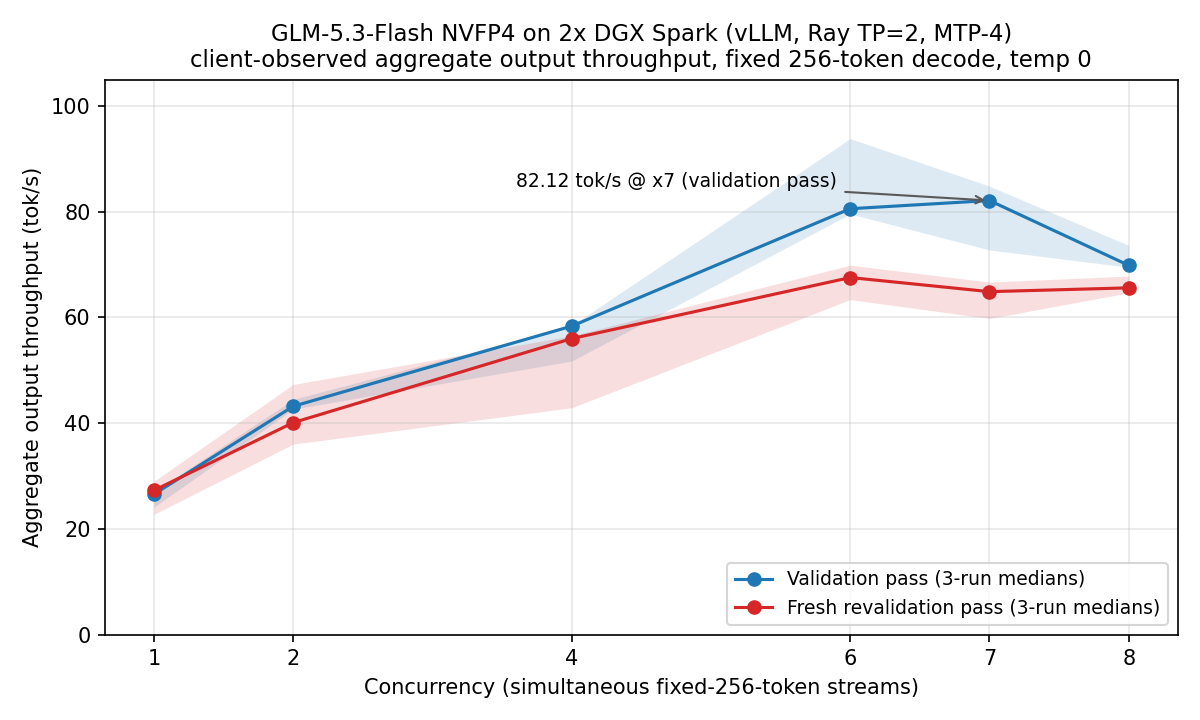

In [9]:
display(Image(filename="../assets/charts/2026-08-27-glm-5.3-flash-nvfp4-2node-tp2-vllm-throughput.png"))

### 2.5 MTP behavior and the DFlash2 variant on the same checkpoint

MTP-4 draft acceptance is workload-dependent (47–73% observed,
mean accepted length 2.7–3.9
tokens), which is why the receipts publish medians and ranges. A second
profile swaps the draft for DFlash2 K=7 on the same NVFP4 target: single-stream
decode swings from **61.34 tok/s** at
91.0% acceptance (structured counting) down to
**35.77 tok/s** at
47.4% (alphabet). Speculation only pays when the draft
guesses right. The DFlash2 draft is CC BY-NC-ND 4.0: evaluation-only.
**Measured.**

In [10]:
g = load_receipt("gates-coldstart-failures.json")
d = load_receipt("dflash2-profile.json")
print("MTP behavior:", g["mtp_behavior"])
print()
render_table(
    ["DFlash2 output shape (c=1)", "Median decode tok/s", "Draft acceptance", "Note"],
    [[row["shape"], row["median_decode_tok_s"], f"{row['draft_acceptance_pct']}%", row["note"]]
     for row in d["prompt_shape_sensitivity"]["rows"]],
)
print()
render_table(
    ["DFlash2 concurrency", "Aggregate tok/s", "Mean stream tok/s", "Mean TTFT (s)", "Acceptance", "Failures"],
    [[f"x{row['concurrency']}", row["aggregate_tok_s"], row["mean_stream_decode_tok_s"],
      row["mean_ttft_s"], f"{row['draft_acceptance_pct']}%", row["failures"]]
     for row in d["decode_concurrency"]["rows"]],
)

MTP behavior: {'draft_acceptance_range_pct': [47, 73], 'mean_accepted_length_range_tokens': [2.7, 3.9], 'note': 'varies by workload and concurrency; why three-run medians and ranges are published'}



| DFlash2 output shape (c=1) | Median decode tok/s | Draft acceptance | Note |
|---|---|---|---|
| count 1->200 | 61.34 | 91.0% | 450 tokens each run; reproduces the linked recipe's ~60.6 tok/s structured result |
| code only | 42.55 | 61.1% | 500 tokens each run |
| alphabet x8 | 35.77 | 47.4% | unreliable stop length (54-94 tokens); not a headline number |

| DFlash2 concurrency | Aggregate tok/s | Mean stream tok/s | Mean TTFT (s) | Acceptance | Failures |
|---|---|---|---|---|---|
| x1 | 24.72 | 25.28 | 0.337 | 30.7% | 0 |
| x2 | 30.94 | 19.88 | 3.825 | 32.4% | 0 |
| x4 | 38.54 | 17.5 | 6.533 | 32.3% | 0 |

### 2.6 Functional gates and cold start

All text gates passed on both passes, through the direct API and the local
proxy alias. The image gate passed on the validation pass, failed on the
final revalidation pass (see 2.7). **Measured.**

In [11]:
g = load_receipt("gates-coldstart-failures.json")
render_table(
    ["Gate (validation pass)", "Result", "Detail"],
    [[row["gate"], row["result"], row["detail"]] for row in g["functional_gates_validation_pass"]],
)
print()
render_table(
    ["Gate (revalidation final pass)", "Result", "Detail"],
    [[row["gate"], row["result"], row["detail"]] for row in g["functional_gates_revalidation_final_pass"]],
)
print()
cs = g["cold_start"]
render_table(["Cold-start stage", "Observed"], [
    ["head launch -> authenticated API ready", f"{cs['head_launch_to_api_ready_s']} s ({cs['head_launch_to_api_ready_human']})"],
    ["rank-0 model load", f"{cs['rank0_model_load_s']} s ({cs['rank0_model_load_gib']} GiB)"],
    ["engine profile/KV/warm-up", f"{cs['engine_profile_kv_warmup_s']} s"],
    ["note", cs["note"]],
])

| Gate (validation pass) | Result | Detail |
|---|---|---|
| low-effort coding | pass | complete Python binary-search implementation, finish_reason=stop, 90 output tokens, 2.715 s |
| high-effort reasoning | pass | reasoning separated from the final $60 answer |
| automatic tool routing | pass | emitted exactly get_weather |
| image description | pass | generated solid-red PNG returned 'Red' |
| OpenCodex via local CLIProxy alias | pass | GLM_LOCAL_OK (local alias) and GLM_PUBLIC_OK (public proxy alias) |
| container stability | pass | both rank containers running, restart count 0 after the full test matrix |

| Gate (revalidation final pass) | Result | Detail |
|---|---|---|
| low-effort coding | pass | 90 tokens in 2.711 s = 33.2 client-observed e2e output tok/s |
| high-effort reasoning | pass | correct $60 final answer with separated reasoning |
| automatic tool routing | pass | emitted exactly get_weather |
| image description | FAIL | HTTP 500; Ray node-memory monitor killed TP0 and vLLM shut down (see vision_uma_failure) |

| Cold-start stage | Observed |
|---|---|
| head launch -> authenticated API ready | 918 s (15 minutes 18 seconds) |
| rank-0 model load | 676.17 s (91.23 GiB) |
| engine profile/KV/warm-up | 133.79 s |
| note | JIT and FlashInfer caches persist in a Docker volume; subsequent starts reuse compiled artifacts |

### 2.7 Coding-agent regression and the vision failure

A fresh ephemeral OpenCodex run through the local proxy alias inspected the
recipe repository with read-only tools: **111,106 input tokens
(0 cached), 4,002 output tokens**, coherent multi-step execution,
no punctuation loop — and it found a real recipe bug. Then the first 32x32
image request on the final pass drove node memory
**6,606,848 bytes over** Ray's 95% threshold; Ray killed TP0 and vLLM exited
(HTTP 500). An earlier start had passed the same gate, so vision is
nondeterministic at this memory margin. **Measured (including the failure).**

In [12]:
g = load_receipt("gates-coldstart-failures.json")
a = g["coding_agent_regression"]; v = g["vision_uma_failure"]
render_table(["Coding-agent regression", "Value"], [
    ["input tokens (0 cached)", f"{a['input_tokens']:,}"],
    ["output tokens", f"{a['output_tokens']:,}"],
    ["coherent commands, exit 0", a["command_executions_exit_zero"]],
    ["repeated-punctuation loop", a["repeated_punctuation_loop"]],
    ["bonus finding", a["bonus_finding"]],
])
print()
render_table(["Vision UMA failure", "Value"], [
    ["trigger", v["trigger"]],
    ["node memory reached", f"{v['node_memory_bytes']:,} bytes"],
    ["Ray 95% threshold", f"{v['ray_95pct_threshold_bytes']:,} bytes"],
    ["over threshold by", f"{v['over_threshold_bytes']:,} bytes"],
    ["sequence", v["sequence"]],
    ["root cause", v["root_cause"]],
    ["nondeterminism", v["nondeterminism"]],
    ["mitigation", v["mitigation"]],
])

| Coding-agent regression | Value |
|---|---|
| input tokens (0 cached) | 111,106 |
| output tokens | 4,002 |
| coherent commands, exit 0 | True |
| repeated-punctuation loop | False |
| bonus finding | independently found a real recipe bug (benchmark.py defaulted to port 8889 while the public recipe serves on 8888) |

| Vision UMA failure | Value |
|---|---|
| trigger | first 32x32 image request on the final pre-restart functional pass |
| node memory reached | 124,136,656,896 bytes |
| Ray 95% threshold | 124,130,050,048 bytes |
| over threshold by | 6,606,848 bytes |
| sequence | Ray killed the TP0 worker, then vLLM shut down (HTTP 500 at the gate) |
| root cause | Ray node-memory monitor, not a malformed model response or CUDA kernel error |
| nondeterminism | an image smoke test passed on a prior start; the path is not production-safe at this margin |
| mitigation | vision is opt-in via --include-vision; lower GPU_MEM_UTIL or pin a smaller KV cache for multimodal production |

## 3. Reproduce

**Hardware.** 2x DGX Spark (GB10, SM121, 128 GiB unified memory per node, one
GPU per node), connected by a direct CX7 RoCE link. ~200 GiB free per node
(~181.29 GiB of weights per node). Docker (no sudo) on both nodes;
passwordless SSH from the head to the worker; the launcher pins the CX7 NICs
for NCCL so connection establishment does not hang.

**Launch** (from the evidence repository at the reviewed revision; provide
the API key via a secret file or your platform secret store — never in
repo files):

```bash
git clone https://github.com/PixelML/GLM-5.3-Flash-NVFP4-Dual-DGX-Spark.git
cd GLM-5.3-Flash-NVFP4-Dual-DGX-Spark
git checkout --detach 3407023e0b8109a1dd12e8a5544e106ca6912afe
umask 077 && openssl rand -hex 32 > .vllm-api-key
VLLM_API_KEY="$(<.vllm-api-key)" ./start.sh
```

**Snapshot download (pinned revision):**

```bash
huggingface-cli download LibertAIDAI/GLM-5.3-Flash-NVFP4 \
  --revision 11d73216cd636238e82e1d77fe1042ffab36e7fa
```

Run the download once on the head, then let the launcher stage the worker
(rsync) — or run it on both nodes with a shared-cache setup.

**Expected boot time.** First start: ~15 minutes head launch to
authenticated API readiness (676.17 s rank-0 model load + 133.79 s
profile/KV/warm-up). JIT and FlashInfer caches persist in a Docker volume;
subsequent starts are faster. Poll `/health` up to 3600 s — 320B-class MoE
init is slow.

**Benchmark harness** (functional gates + concurrency matrix + uncached
prefill):

```bash
./benchmark.py --secret-file .vllm-api-key --concurrency 1,2,4,8
./prefill-benchmark.py --secret-file .vllm-api-key
```

**Point this notebook at your own endpoint.** Set `GLM_ENDPOINT` to your
OpenAI-compatible base URL (for example `http://<your-host>:8888/v1`) and
set `LIVE = True` in the status cell, then re-run top to bottom. The
live harness re-runs the fixed 256-token c=1 decode protocol and counts
tokens from the final usage object.

## 4. Appendix

<details>
<summary>What went wrong, how the approach evolved, limits, and evidence
links</summary>

### SGLang was rejected on GB10 for this checkpoint

The official SGLang path was tried first with TP=2/EP=2, online ModelOpt
NVFP4, FP8 KV, and the available SM120/SM121 sparse-MLA backend. Weight
loading completed in **1880.41 seconds**, but the first real decode failed: the packed
SM120 GLM kernel requires `qk_rope_head_dim=64` and query dimension 576,
while GLM-5.3 is NoPE with `qk_rope_head_dim=0` and query dimension 512.
TensorRT-LLM DSA also rejected SM121, and TileLang DSA exceeded GB10's
allowed dynamic shared memory. The selected vLLM patch routes SM121 through
the SM90 NoPE sparse-MLA + FA2 implementation instead of altering the
checkpoint. **Measured (negative result).**

### x8 queues; both decode passes are retained

At c=8 vLLM reports seven running and one waiting at ~96% KV use: TTFT rises
(2.908 s validation pass, 4.684 s fresh pass) and aggregate throughput drops
below the c=7/c=6 sweet spots. The fresh pass's best median
(67.55 tok/s @ c=6) is materially lower than the validation pass's
(82.12 tok/s @ c=7); the receipts keep both rather than replacing the
earlier number with a cherry-picked peak. **Measured.**

### Vision (multimodal) is not production-safe on this profile

See section 2.7: the first image compile on the 0.84 UMA budget can cross
Ray's node-memory threshold by ~6.6 MB and take the engine down. One start
passed the same gate, so the failure is nondeterministic. Mitigations per
the receipts: keep vision opt-in (`--include-vision`), lower `GPU_MEM_UTIL`
or pin a smaller KV cache, and do not disable Ray's memory monitor as a
first fix (that risks a host OOM instead of a controlled kill).
**Measured.**

### GPU_MEM_UTIL=0.90 fails

The upstream recipe documentation states `GPU_MEM_UTIL=0.90` fails the
free-memory check on GB10; 0.84 is the validated budget (leaves room for
Ray's object store and the multimodal margin). **Community-reported**
(upstream recipe docs, not re-measured by PixelML).

### Quality/accuracy: untested

No scored quality evidence exists for this checkpoint on DGX Spark. The
separate fidelity-eval scaffold (`PixelML/GLM-5.3-Flash-DGX-Spark-Eval` @
`b81f7eca052d0f81a831527bbf7a6b3ce8b49d0b`) plans an exllamav3-qbench NVFP4
vs FP8-reference comparison; its arm64 extension build + import smoke passed
on 2026-08-31 (driver 580.173.02, CUDA 13.0, torch 2.13.0+cu130), but the
full qbench run had **not** been executed as of that receipt. Its own README
states no benchmark numbers in it are real yet. **Untested.**

### Related lanes (different quantization, out of scope here)

- **EXL3/TR3 4-bpw + DFlash2** on the same model family reached 66.30 tok/s
  single-stream structured / 154.86 aggregate tok/s @ c=4 with a 900K
  context ceiling and a 299,527-token stress pass at 815.92 input tok/s —
  but it is a different quantization (ShapleyMCG 1.0 source-available
  checkpoint) and its receipts are not part of this NVFP4 bundle.
- **Single-node (1x Spark)**: untested; 181.29 GiB of weights does not fit
  one 128 GiB UMA node. **Inferred, not measured.**

### Receipt gaps

- Power, temperature, and fan telemetry were not captured in any source
  receipt (the power/thermal columns above are gaps, not zeros).
- The serving-lane driver/OS/container digest is not recorded for the
  2026-08-27 passes (the DFlash2 profile records its image digest;
  `sha256:4def0ef6…`).
- The evidence repo publishes medians and ranges (not raw per-request dumps)
  for these two passes; the raw JSON dumps it publishes belong to the EXL3
  profile and are deliberately not copied here.
- The MTP acceptance range (47–73%) is reported as a range over workloads
  and concurrencies, not per-row.

### Sanitization

The upstream receipt copies under `results/2026-08-27-glm-5.3-flash-nvfp4-2node/upstream/` had
private-infrastructure identifiers replaced with generic terms: the private
cluster name, node-to-node private IPs, NIC interface names, overlay-network
route details, local proxy alias names, and absolute cold-start clock
timestamps (durations kept). Measured values are unchanged. The full
redaction log is in `results/2026-08-27-glm-5.3-flash-nvfp4-2node/README.md`.

### Evidence links

- Validation receipt (upstream): `results/UPSTREAM-2026-08-27.md` in
  [PixelML/GLM-5.3-Flash-NVFP4-Dual-DGX-Spark](https://github.com/PixelML/GLM-5.3-Flash-NVFP4-Dual-DGX-Spark/tree/3407023e0b8109a1dd12e8a5544e106ca6912afe)
  @ `3407023e0b8109a1dd12e8a5544e106ca6912afe` (MIT).
- Revalidation receipt (upstream): `results/UPSTREAM-2026-08-27-REVALIDATION.md`
  in the same repository and revision.
- DFlash2 receipt (upstream): `results/UPSTREAM-2026-08-28-DFLASH2.md` in the
  same repository and revision.
- Checkpoint: [LibertAIDAI/GLM-5.3-Flash-NVFP4](https://huggingface.co/LibertAIDAI/GLM-5.3-Flash-NVFP4)
  @ `11d73216cd636238e82e1d77fe1042ffab36e7fa`.
- DFlash2 port credit:
  [tonyd2wild/GLM-5.3-Flash-NVFP4-DFlash2-2x-DGX-Spark](https://github.com/tonyd2wild/GLM-5.3-Flash-NVFP4-DFlash2-2x-DGX-Spark);
  draft model by IncoAI, CC BY-NC-ND 4.0 (evaluation-only).
- Club context: [cookbook profile selector](../docs/cookbook/glm-5.3-flash-dgx-spark.md),
  [benchmark method](../docs/BENCHMARK-METHOD.md).

</details>